In [3]:
import numpy as np
import sunode
import sunode.wrappers.as_pytensor
import matplotlib.pyplot as plt
from scipy.stats import halfnorm
from scipy.stats import lognorm
import arviz as az
import pymc as pm
import mich_ment_MA as MM

### First we will generate some synthetic data for testing
We will use the following parameters:
- kOn = 1
- kOff = 1e-1
- kCat = 1e-2
- Et = 20.0 
- S(0) = 10.0
- P(0) = 0.0
- E(0) = Et
- ES(0) = 0.0

We will add some Gaussian noise to the data, which will be direct measurements of S(t) and P(t). 

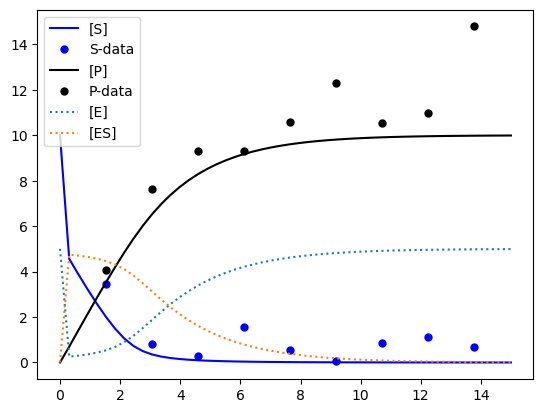

In [9]:
# load the necessary dictionaries
params = MM.mich_ment_get_params()
states =MM.mich_ment_get_states()
nparams = len(params)
nstates = len(states)

# create sunode problem
problem = sunode.SympyProblem(
    params=params,
    states=states,
    rhs_sympy=MM.mich_ment_RHS_odeEnzyme,
    # specify variables to take gradients wrt
    derivative_params=(),
)

# set up solver
solver = sunode.solver.Solver(problem, solver='BDF')

# Initial conditions
y0 = np.zeros((), dtype=problem.state_dtype)
y0['S'] = 10.0
y0['P'] = 0.0
y0['E'] = 5.0
y0['ES'] = 0.0

# evaluate the solution at these times
tvals = np.linspace(0, 15, 50)

# nominal parameter values
solver.set_params_dict({
    'kOn': 10.0,
    'kOff': 2.0,
    'kCat': 0.5,
})

# run solver
yout = solver.make_output_buffers(tvals)
solver.solve(t0=0, tvals=tvals, y0=y0, y_out=yout)

# data
tvals_data = tvals[5:50:5]
Sdata = np.copy(yout.view(problem.state_dtype)['S'][5:50:5])
Sdata += halfnorm.rvs(size=Sdata.shape)
Pdata = np.copy(yout.view(problem.state_dtype)['P'][5:50:5])
Pdata += lognorm.rvs(1, size=Pdata.shape)

# plot
fig, ax = plt.subplots()
ax.plot(tvals, yout.view(problem.state_dtype)['S'], 'b')
ax.plot(tvals_data, Sdata, 'b.', markersize=10)
ax.plot(tvals, yout.view(problem.state_dtype)['P'], 'k')
ax.plot(tvals_data, Pdata, 'k.', markersize=10)
ax.plot(tvals, yout.view(problem.state_dtype)['E'], ':')
ax.plot(tvals, yout.view(problem.state_dtype)['ES'], ':')
ax.legend(('[S]', 'S-data', '[P]', 'P-data', '[E]', '[ES]'))

In [31]:
# Set up the PyMC model
with pm.Model() as model:
    # priors on the model parameters
    kOn = pm.LogNormal('kOn', mu=2.5, sigma=0.25)
    kOff = pm.LogNormal('kOff', mu=0.0, sigma=0.5)
    kCat = pm.LogNormal('kCat', mu=0.0, sigma=1)

    # construct the sunode model, this takes PyTensors for the free parameters
    y_hat, _, problem, solver, _, _ = sunode.wrappers.as_pytensor.solve_ivp(
        # inital conditions
        y0 = {
            'S': (np.array(10.0), ()),
            'P': (np.array(0.0), ()),
            'E': (np.array(5.0), ()),
            'ES': (np.array(0.0), ()),
        },
        params={
            'kOn': (kOn, ()),
            'kOff': (kOff, ()),
            'kCat': (kCat, ()),
            '_dummy': (np.array(1,), ()) # need to add a dummy variable due to a bug in sunode (:
        },
        rhs=MM.mich_ment_RHS_odeEnzyme,
        tvals=tvals_data,
        t0=0.0,
    )

    # lastly the observation model
    # Assume we know the distribution of the measurements, but they have an unknown
    # sigma
    sd = pm.HalfNormal('sd')
    pm.TruncatedNormal('S', mu=y_hat['S'], sigma=sd, lower=0.0, observed=Sdata)
    pm.Normal('P', mu=y_hat['P'], sigma=sd, observed=Pdata)

In [28]:
# now we can try to sample
with model:
    idata = pm.sample(tune=10, draws=200, cores=1, chains=6)

In [33]:
with model:
    idata2 = pm.sample(tune=10, draws=200, cores=2, chains=2)

Only 200 samples in chain.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...

[CVODEA ERROR]  CVodeF
  At t = 0.552706, mxstep steps taken before reaching tout.


[CVODEA ERROR]  CVodeF
  At t = 0.995009, mxstep steps taken before reaching tout.


[CVODEA ERROR]  CVodeF
  At t = 0.552706, mxstep steps taken before reaching tout.


[CVODEA ERROR]  CVodeF
  At t = 0.995009, mxstep steps taken before reaching tout.

Multiprocess sampling (2 chains in 2 jobs)
NUTS: [kOn, kOff, kCat, sd]


TypeError: cannot pickle '_cffi_backend._CDataBase' object